<h1 style="text-align: center;">[Prediksi Customer Churn pada Perusahaan Telco]</h1>
<h3 style="text-align: center;">[Firsa Adam, Yoanita Dwi Harlandi Dan Andre Yonathan]</h3>

---

## **Section 0. Setup**

>   *Tujuan:* Menyiapkan environment kerja (import library, konfigurasi global) supaya proses selanjutnya konsisten dan reproducible.

**0.1 Import Library**

>   *Tujuan:* Memuat semua library yang dibutuhkan di satu tempat di awal, supaya dependency notebook mudah dilacak.

In [1]:
# import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tambahkan import lain sesuai kebutuhan (sklearn, dll) di sini

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectFpr
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import make_scorer, fbeta_score

from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.model_selection import learning_curve

**0.2 Global Configuration**

>   *Tujuan:* Menetapkan parameter global seperti random_state di satu tempat, supaya semua proses (split, model, CV) memakai nilai yang sama.

> **Catatan** Selalu set `RANDOM_STATE` di satu tempat dan pakai variabel yang sama di semua proses (train_test_split, model, cross-validation). Ini membuat hasil eksperimenmu **reproducible** - orang lain (atau kamu sendiri, minggu depan) bisa menjalankan ulang notebook dan dapat hasil yang sama persis.

In [3]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
TARGET_COL = 'Churn'                          # kolom target
POSITIVE_CLASS = 'Yes'

## **Section 1. Business Understanding**

>   *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah yang bisa diselesaikan dengan machine learning, sebelum menyentuh data sama sekali.

**1.1 Context**

> *Tujuan:* Menjelaskan latar belakang bisnis: siapa stakeholder-nya dan kenapa masalah ini perlu diselesaikan sekarang.

Perusahaan telekomunikasi (telco) menjalankan model bisnis subscription-based, di mana pendapatan utama berasal dari pelanggan yang membayar layanan secara berkala setiap bulan. Dalam model bisnis seperti ini, mempertahankan pelanggan (retention) menjadi salah satu faktor utama untuk menjaga recurring revenue, karena setiap pelanggan yang keluar (churn) berarti hilangnya pendapatan berulang sekaligus menambah beban biaya akuisisi pelanggan baru untuk menggantikannya

Berdasarkan data historis (4.930 pelanggan), tercatat **churn rate sebesar 26,69%**, lebih tinggi dibandingkan benchmark rata-rata industri telekomunikasi yang berada di kisaran **21,5–22%** (https://focus-digital.co/average-churn-rate-by-industry/). Selisih ini menunjukkan adanya ruang perbaikan jika dibandingkan dengan kondisi industri secara umum.

Berdasarkan riset Harvard Business Review dan Frederick Reichheld (Bain & Company), biaya untuk memperoleh pelanggan baru diperkirakan 5–25 kali lebih tinggi dibandingkan biaya mempertahankan pelanggan yang sudah ada, tergantung industri. Karena itu, kemampuan mengidentifikasi pelanggan berisiko churn sejak dini menjadi krusial agar upaya retensi dapat dilakukan secara proaktif — bukan reaktif setelah pelanggan benar-benar berhenti.

Pola churn pelanggan pada dasarnya dipengaruhi oleh kombinasi banyak faktor (jenis kontrak, layanan tambahan yang digunakan, lama berlangganan, biaya bulanan, dan lainnya) yang sulit ditangkap secara akurat dengan aturan bisnis manual sederhana. Karena itu, dibutuhkan pendekatan machine learning yang mampu mempelajari pola dari data historis pelanggan.

Pihak yang berkepentingan langsung terhadap hasil project ini:

•	**Tim CRM** — menggunakan skor risiko churn untuk mengidentifikasi pelanggan berisiko tinggi dan menjalankan program retensi secara tersegmentasi (high/medium/low risk).

•	**Tim Marketing** — memanfaatkan daftar pelanggan berisiko untuk menjalankan kampanye retensi yang lebih tepat sasaran.

•	**Tim Product** — menggunakan feature importance dan insight model untuk mengevaluasi produk, kontrak, atau layanan yang paling berkontribusi terhadap churn.


**1.2 Problem Statements**

> *Tujuan:* Merumuskan masalah secara spesifik dan terukur, biasanya dalam bentuk pertanyaan yang bisa dijawab lewat data.

Berdasarkan konteks bisnis di atas, masalah dirumuskan menjadi pertanyaan yang dapat dijawab menggunakan data pelanggan yang tersedia:

1.	Pelanggan dengan karakteristik seperti apa (jenis kontrak, layanan tambahan, lama berlangganan, biaya bulanan, dsb.) yang memiliki risiko churn paling tinggi?
2.	Dapatkah dibangun model klasifikasi yang mampu memprediksi probabilitas seorang pelanggan akan churn berdasarkan atribut historisnya, sehingga tim CRM dan Marketing dapat melakukan intervensi retensi lebih awal?
3.	Bagaimana hasil prediksi model dapat diterjemahkan menjadi estimasi dampak bisnis (pendapatan yang berpotensi dipertahankan), sehingga dapat digunakan sebagai dasar keputusan program retensi?


**1.3 Goals**

> *Tujuan:* Menetapkan target yang ingin dicapai proyek ini, sebagai turunan langsung dari problem statement di atas.
Sebagai turunan langsung dari problem statement di atas, project ini bertujuan untuk:

1.	Mendukung penurunan churn rate dari kondisi historis 26,69% menuju mendekati benchmark industri telekomunikasi (±22%), melalui identifikasi pelanggan berisiko tinggi sejak dini.
2.	Menyediakan skor risiko churn (churn probability) per pelanggan yang dapat digunakan tim CRM dan Marketing untuk memprioritaskan dan menargetkan program retensi secara lebih efisien.
3.	Mengungkap faktor-faktor pendorong churn sebagai bahan evaluasi tim Product terhadap layanan, kontrak, atau fitur yang paling berkontribusi terhadap keputusan pelanggan untuk berhenti berlangganan.


**1.4 Analytical Approach**

> *Tujuan:* Menentukan pendekatan analitis/teknis (misal klasifikasi atau regresi) yang akan dipakai untuk mencapai goals.
Karena target (`Churn`) bersifat kategorikal biner (*Yes*/*No*), masalah ini didekati sebagai **binary classification**. Pendekatan yang akan dilakukan pada tahap-tahap selanjutnya:

•	Membangun dan membandingkan beberapa algoritma klasifikasi (Logistic Regression sebagai baseline yang mudah diinterpretasi, KNN, Decision Tree, Random Forest, AdaBoost, serta metode ensemble Voting/Stacking/Bagging) melalui 5-fold cross-validation.

•	Melakukan hyperparameter tuning pada kandidat model dengan performa terbaik dari tahap benchmarking.

•	Menangani ketidakseimbangan distribusi target (±27% churn vs ±73% tidak churn) menggunakan class_weight, atau oversampling/undersampling seperti SMOTE, sesuai mitigasi risiko teknis yang ditetapkan.

•	Menggunakan output probabilitas model sebagai churn risk score (bukan hanya label biner), sehingga dapat diperingkat oleh tim CRM/Marketing untuk menentukan prioritas tindak lanjut.

•	Melakukan interpretasi model menggunakan SHAP untuk menjawab Problem Statement mengenai faktor pendorong churn, sekaligus membangun kepercayaan stakeholder bisnis terhadap hasil model.

•	Model dievaluasi ulang (performance monitoring) setiap kuartal; retraining dilakukan apabila Recall atau ROC-AUC turun lebih dari 5% selama dua kuartal berturut-turut, atau terdeteksi perubahan distribusi data (data drift).


**1.5 Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

> *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

**Business Metric**

Setiap pelanggan yang sebenarnya akan churn namun tidak terdeteksi oleh model (False Negative) berarti hilangnya kesempatan untuk menjalankan program retensi dan berpotensi kehilangan recurring revenue dari pelanggan tersebut. Sebaliknya, setiap pelanggan yang diprediksi churn padahal sebenarnya tidak (False Positive) menyebabkan biaya operasional retensi (follow-up oleh CRM/Marketing) yang sebetulnya tidak diperlukan.

Karena biaya kehilangan pelanggan (False Negative) pada umumnya jauh lebih besar dibandingkan biaya follow-up yang terbuang (False Positive) — mengingat biaya akuisisi pelanggan baru jauh lebih tinggi daripada biaya retensi — model dioptimalkan dengan memprioritaskan Recall, tanpa mengabaikan Precision, agar kapasitas dan anggaran tim retensi tetap terjaga.


**Machine Learning Evaluation Metric**

•	Recall (kelas Churn) dijadikan metrik utama, karena merepresentasikan seberapa banyak pelanggan yang benar-benar akan churn berhasil terdeteksi oleh model.

•	Precision tetap dipantau agar jumlah pelanggan yang menerima program retensi masih sesuai dengan kapasitas dan anggaran perusahaan.

•	ROC-AUC digunakan untuk melihat kemampuan model membedakan pelanggan churn dan tidak churn secara keseluruhan.

•	Baseline pembanding: model Logistic Regression sederhana, sebagai acuan minimal sebelum mempertimbangkan model yang lebih kompleks.

•	Akurasi tidak dijadikan metrik utama karena distribusi target tidak seimbang (±27:73), sehingga akurasi tinggi berpotensi menyesatkan (model bisa saja hanya menebak mayoritas kelas "tidak churn").


**1.6 Success Criteria**

> *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.
Model dianggap layak digunakan apabila, pada data testing/unseen, mencapai:

•	Recall (kelas Churn) > 75%

•	ROC-AUC ≥ 0.80

Dari sisi bisnis, keberhasilan project diukur dari kontribusinya terhadap penurunan churn rate dari 26,69% menuju mendekati benchmark industri (±22%).

**Ilustrasi potensi dampak bisnis (simulasi)**
Simulasi berikut disusun untuk mengilustrasikan potensi dampak bisnis apabila program retensi berhasil menurunkan churn rate ke level benchmark industri — bukan hasil implementasi aktual.

•	Kondisi saat ini: churn rate 26,69% → 1.316 pelanggan churn (dari total 4.930 pelanggan).

•	Target: churn rate 22% → 1.085 pelanggan churn, sehingga sekitar 231 pelanggan berpotensi dipertahankan.

•	Dengan asumsi revenue $65 per pelanggan per bulan, potensi pendapatan yang dipertahankan diperkirakan sekitar $15,041 per bulan, atau sekitar $180,492 per tahun (asumsi pelanggan yang dipertahankan tetap berlangganan selama 12 bulan penuh).


> **Catatan:** Angka simulasi di atas bersifat ilustratif dan bergantung pada beberapa asumsi (revenue per pelanggan flat, retensi penuh 12 bulan, dan target churn rate mengacu pada benchmark industri). Angka ini sebaiknya dikonfirmasi ulang bersama tim Finance/CRM sebelum digunakan sebagai dasar keputusan bisnis.

## **Section 2. Data Understanding**

>   *Tujuan:* Mengenali data secara umum - bentuk, tipe, dan makna tiap fitur - sebelum melakukan pembersihan atau analisis mendalam.

**2.1 General Information**

>   *Tujuan:* Melihat ukuran, tipe data, dan struktur umum dataset (jumlah baris, kolom, tipe data tiap kolom).

In [4]:
DATA_PATH = "../data/raw/data_telco_customer_churn.csv"
df = pd.read_csv(DATA_PATH)

In [5]:
df.head()

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.90,Yes
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.65,No
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.85,Yes
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.65,No
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.60,No


In [6]:
df.shape

(4930, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        4930 non-null   object 
 1   tenure            4930 non-null   int64  
 2   OnlineSecurity    4930 non-null   object 
 3   OnlineBackup      4930 non-null   object 
 4   InternetService   4930 non-null   object 
 5   DeviceProtection  4930 non-null   object 
 6   TechSupport       4930 non-null   object 
 7   Contract          4930 non-null   object 
 8   PaperlessBilling  4930 non-null   object 
 9   MonthlyCharges    4930 non-null   float64
 10  Churn             4930 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 423.8+ KB


In [8]:
print(df.isnull().sum())

Dependents          0
tenure              0
OnlineSecurity      0
OnlineBackup        0
InternetService     0
DeviceProtection    0
TechSupport         0
Contract            0
PaperlessBilling    0
MonthlyCharges      0
Churn               0
dtype: int64


**Interpretasi:**

- **Tidak ditemukan missing value** pada seluruh kolom — setiap kolom memiliki 4.930 baris non-null, sama dengan total baris. Ini menyederhanakan tahap Data Cleaning karena tidak diperlukan strategi imputasi.
- Tipe data terbagi menjadi tiga kelompok: **numerik** (`tenure` bertipe `int64`, `MonthlyCharges` bertipe `float64`), dan **kategorikal/object** (9 kolom sisanya, termasuk target `Churn`).
- Karena mayoritas fitur berupa data kategorikal (object), tahap Data Preparation nanti perlu melibatkan proses *encoding* (mis. One-Hot Encoding) sebelum data bisa dipakai oleh algoritma machine learning.

**2.2 Feature Information**

>   *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap masalah bisnis di Section 1.

| Feature | Type | Description | Impact to Business |
|---|---|---|---|
| `Dependents` | Kategorikal (Yes/No) | Status apakah pelanggan memiliki tanggungan | Pelanggan dengan tanggungan cenderung punya kebutuhan komunikasi/layanan yang lebih stabil, berpotensi memengaruhi loyalitas |
| `tenure` | Numerik (0-72 bulan) | Lama berlangganan pelanggan dalam satuan bulan | Indikator loyalitas langsung; pelanggan baru (tenure rendah) secara umum lebih rentan churn dibanding pelanggan lama |
| `OnlineSecurity` | Kategorikal (Yes/No/No internet service) | Status kepemilikan layanan keamanan online | Layanan tambahan yang bisa meningkatkan *stickiness* pelanggan terhadap provider |
| `OnlineBackup` | Kategorikal (Yes/No/No internet service) | Status kepemilikan layanan backup online | Sama seperti di atas -- layanan add-on yang berpotensi menurunkan risiko churn |
| `InternetService` | Kategorikal (DSL/Fiber optic/No) | Jenis layanan internet yang digunakan pelanggan | Jenis layanan berkaitan langsung dengan kepuasan & biaya; relevan untuk mengevaluasi kualitas layanan per jenis internet |
| `DeviceProtection` | Kategorikal (Yes/No/No internet service) | Status kepemilikan layanan proteksi perangkat | Layanan add-on yang berpotensi meningkatkan retensi pelanggan |
| `TechSupport` | Kategorikal (Yes/No/No internet service) | Status kepemilikan layanan dukungan teknis | Pelanggan tanpa dukungan teknis lebih mungkin mengalami masalah tak terselesaikan yang mendorong churn |
| `Contract` | Kategorikal (Month-to-month/One year/Two year) | Jenis kontrak berlangganan | Komitmen kontrak jangka panjang secara struktural menurunkan kemungkinan churn (biaya berpindah lebih tinggi) |
| `PaperlessBilling` | Kategorikal (Yes/No) | Status penggunaan tagihan tanpa kertas | Proxy dari preferensi/kenyamanan digital pelanggan, dapat berkorelasi dengan segmen demografis tertentu |
| `MonthlyCharges` | Numerik (18.8-118.65) | Besaran tagihan layanan per bulan | Biaya yang lebih tinggi dapat menjadi pemicu churn jika pelanggan merasa tidak sepadan dengan value yang diterima |
| `Churn` (target) | Kategorikal (Yes/No) | Status apakah pelanggan berhenti berlangganan | Variabel target yang ingin diprediksi oleh model |

**2.3 Statistics Summary**

>   *Tujuan:* Melihat ringkasan statistik deskriptif (mean, median, min-max, dsb) untuk menangkap gambaran awal distribusi data.

In [9]:
# df.describe(include='all')
df.describe(include='all')

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
count,4930,4930.000000,4930,4930,4930,4930,4930,4930,4930,4930.000000,4930
unique,2,NaN,3,3,3,3,3,3,2,NaN,2
top,No,NaN,No,No,Fiber optic,No,No,Month-to-month,Yes,NaN,No
freq,3446,NaN,2445,2172,2172,2186,2467,2721,2957,NaN,3614
mean,NaN,32.401217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.883032,NaN
std,NaN,24.501193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.923960,NaN
min,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.800000,NaN
25%,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.050000,NaN
50%,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN
75%,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN


**Interpretasi:**

*Fitur numerik:*
- `tenure` memiliki rentang 0-72 bulan dengan rata-rata sekitar 32,4 bulan dan median 29 bulan. Sebaran cukup lebar (std sekitar 24,5), menunjukkan basis pelanggan mencakup baik pelanggan yang baru bergabung maupun yang sudah sangat lama berlangganan.
- `MonthlyCharges` berkisar 18,8-118,65 dengan rata-rata sekitar 64,9. Median (70,35) lebih tinggi dari mean, mengindikasikan sedikit kemencengan (*skew*) ke arah nilai tagihan yang lebih rendah.

*Fitur kategorikal:*
- `Contract`: kategori terbanyak adalah **Month-to-month** (2.721 dari 4.930 pelanggan, sekitar 55%) -- konsisten dengan temuan sebelumnya bahwa kontrak bulanan memiliki churn rate tertinggi (43,3%), sehingga porsi signifikan pelanggan berada pada segmen paling berisiko.
- `InternetService`: kategori terbanyak adalah **Fiber optic** (2.172 pelanggan) -- juga selaras dengan temuan bahwa segmen ini memiliki churn rate tertinggi di antara jenis layanan internet.
- `TechSupport` dan `OnlineSecurity`: mayoritas pelanggan (masing-masing 2.467 dan 2.445) **tidak** memiliki layanan tersebut -- berpotensi menjadi salah satu pendorong churn utama, sesuai temuan pada Data Understanding sebelumnya.
- `Churn`: dari 4.930 pelanggan, 3.614 berlabel "No" dan sisanya "Yes" -- mengonfirmasi kembali proporsi churn sekitar 26,9%, yang tergolong **imbalanced** dan perlu ditangani pada tahap modeling.

## **Section 3. Data Cleaning**

>   *Tujuan:* Memastikan data bebas dari masalah kualitas (missing value, duplikat, inkonsistensi) sebelum dipakai lebih lanjut.

**3.1 Missing Values**

>   *Tujuan:* Mengidentifikasi kolom yang punya data hilang dan menentukan strategi menanganinya (drop, imputasi, atau dibiarkan dengan alasan tertentu).

In [10]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,Dependents,object,0,0.0,2,"[No, Yes]"
1,tenure,int64,0,0.0,73,"[60, 17]"
2,OnlineSecurity,object,0,0.0,3,"[Yes, No]"
3,OnlineBackup,object,0,0.0,3,"[Yes, No]"
4,InternetService,object,0,0.0,3,"[DSL, No]"
5,DeviceProtection,object,0,0.0,3,"[No internet service, Yes]"
6,TechSupport,object,0,0.0,3,"[No internet service, No]"
7,Contract,object,0,0.0,3,"[Month-to-month, Two year]"
8,PaperlessBilling,object,0,0.0,2,"[No, Yes]"
9,MonthlyCharges,float64,0,0.0,1422,"[61.55, 30.25]"


**3.2 Duplicated Values**

>   *Tujuan:* Mengecek baris data yang terduplikasi penuh maupun sebagian (misal duplikat berdasarkan ID).

In [11]:
# TODO: duplicated check
df.duplicated().sum()

np.int64(77)

In [12]:
# melihat baris duplikat (termasuk pasangannya)
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
3246,No,1,No,No,DSL,No,No,Month-to-month,No,25.05,Yes
3863,No,1,No,No,DSL,No,No,Month-to-month,No,25.05,Yes
436,No,1,No,No,DSL,No,No,Month-to-month,No,25.25,No
4452,No,1,No,No,DSL,No,No,Month-to-month,No,25.25,No
871,No,1,No,No,DSL,No,No,Month-to-month,No,44.40,Yes
4399,No,1,No,No,DSL,No,No,Month-to-month,No,44.40,Yes
1312,No,1,No,No,DSL,No,No,Month-to-month,No,45.30,Yes
4289,No,1,No,No,DSL,No,No,Month-to-month,No,45.30,Yes
1701,No,1,No,No,DSL,No,No,Month-to-month,Yes,45.30,Yes
3043,No,1,No,No,DSL,No,No,Month-to-month,Yes,45.30,Yes


In [13]:
# bandingkan proporsi Churn: baris duplikat vs keseluruhan data
print("Churn - baris duplikat:")
print(df[df.duplicated(keep=False)]['Churn'].value_counts(normalize=True))

print("\nChurn - keseluruhan data:")
print(df['Churn'].value_counts(normalize=True))

Churn - baris duplikat:
Churn
No     0.643836
Yes    0.356164
Name: proportion, dtype: float64

Churn - keseluruhan data:
Churn
No     0.733063
Yes    0.266937
Name: proportion, dtype: float64


Interpretasi:
Ditemukan 77 baris duplikat penuh (146 baris total termasuk pasangannya). Dataset ini tidak memiliki customer_id, sehingga kombinasi kolom yang identik berpotensi berasal dari pelanggan berbeda yang kebetulan mirip. Namun, karena MonthlyCharges bersifat kontinu dan bervariasi bebas antar baris meski kombinasi kategori+tenure sama, kemungkinan dua pelanggan berbeda memiliki MonthlyCharges yang identik sampai 2 desimal sangat kecil. Oleh karena itu, baris duplikat ini kemungkinan besar merupakan hasil duplikasi pencatatan (data entry), sehingga aman untuk dihapus.

In [14]:
# drop baris duplikat
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(4853, 11)

In [15]:
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
print(churn_pct)

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


Setelah menghapus 77 baris duplikat, jumlah data menjadi 4.853 baris. Proporsi distribusi target (Churn) relatif tidak berubah (26,54% vs 26,69% sebelumnya), mengonfirmasi bahwa penghapusan duplikat tidak mengubah karakteristik data secara signifikan.

In [16]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,Dependents,object,0,0.0,2,"[Yes, No]"
1,tenure,int64,0,0.0,73,"[39, 28]"
2,OnlineSecurity,object,0,0.0,3,"[No, No internet service]"
3,OnlineBackup,object,0,0.0,3,"[Yes, No internet service]"
4,InternetService,object,0,0.0,3,"[Fiber optic, DSL]"
5,DeviceProtection,object,0,0.0,3,"[No, No internet service]"
6,TechSupport,object,0,0.0,3,"[No, No internet service]"
7,Contract,object,0,0.0,3,"[Two year, Month-to-month]"
8,PaperlessBilling,object,0,0.0,2,"[No, Yes]"
9,MonthlyCharges,float64,0,0.0,1422,"[45.0, 53.45]"


**3.3 Data Consistency Check**
- Spelling errors / typo pada kategori
- Inkonsistensi kapitalisasi & format penulisan
- Whitespace tersembunyi

>   *Tujuan:* Menyeragamkan penulisan nilai kategorikal supaya kategori yang sebenarnya sama tidak terbaca sebagai kategori berbeda oleh model.

>   Jangan hanya cek typo. Kesalahan yang jauh lebih sering muncul di data nyata adalah inkonsistensi format, misalnya kategori yang sama tapi ditulis berbeda seperti `"Yes"`, `"yes"`, dan `"YES "` (dengan spasi tersembunyi) - ini dianggap 3 kategori berbeda oleh model kalau tidak dibersihkan.

In [17]:
df['Dependents'].value_counts().reset_index()

,Dependents,count
0,No,3380
1,Yes,1473


In [18]:
df['OnlineSecurity'].value_counts().reset_index()

,OnlineSecurity,count
0,No,2420
1,Yes,1430
2,No internet service,1003


In [19]:
df['OnlineBackup'].value_counts().reset_index()

,OnlineBackup,count
0,No,2148
1,Yes,1702
2,No internet service,1003


In [20]:
df['InternetService'].value_counts().reset_index()

,InternetService,count
0,Fiber optic,2154
1,DSL,1696
2,No,1003


In [21]:
df['DeviceProtection'].value_counts().reset_index()

,DeviceProtection,count
0,No,2162
1,Yes,1688
2,No internet service,1003


In [22]:
df['TechSupport'].value_counts().reset_index()

,TechSupport,count
0,No,2442
1,Yes,1408
2,No internet service,1003


In [23]:
df['Contract'].value_counts().reset_index()

,Contract,count
0,Month-to-month,2665
1,Two year,1143
2,One year,1045


In [24]:
df['PaperlessBilling'].value_counts().reset_index()

,PaperlessBilling,count
0,Yes,2925
1,No,1928


Pengecekan dilakukan terhadap seluruh kolom kategorikal (`Dependents`, `OnlineSecurity`, `OnlineBackup`, `InternetService`, `DeviceProtection`, `TechSupport`, `Contract`, `PaperlessBilling`) dengan melihat seluruh nilai unik pada masing-masing kolom. Tidak ditemukan spelling error/typo, inkonsistensi kapitalisasi, maupun whitespace tersembunyi — sehingga tidak diperlukan proses standarisasi lebih lanjut pada tahap ini.

**3.4 Identify Anomaly Values**
- Check Distribution (Numerical Variable)
- Check Cardinality (Categorical Variable)

>   *Tujuan:* Mendeteksi nilai yang secara statistik tidak wajar (outlier pada numerik, kategori dengan cardinality aneh pada kategorikal).

In [25]:
df.describe()

,tenure,MonthlyCharges
count,4853.000000,4853.000000
mean,32.679992,65.321543
std,24.395554,29.783655
min,0.000000,18.800000
25%,9.000000,40.050000
50%,29.000000,70.600000
75%,56.000000,90.050000
max,72.000000,118.650000


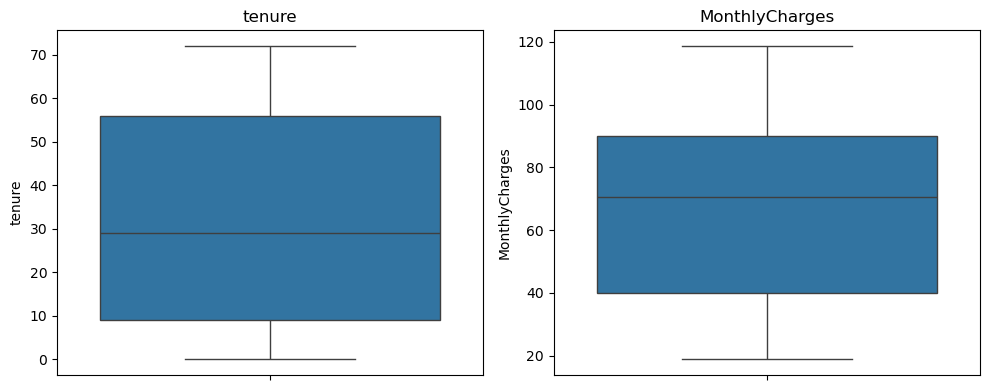

In [26]:
import matplotlib.pyplot as plt

num_cols = ['tenure', 'MonthlyCharges']

# visual: boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [27]:
# statistik: deteksi outlier pakai metode IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'--- {col} ---')
    print(f'Q1={Q1}, Q3={Q3}, IQR={IQR}')
    print(f'Batas bawah={lower}, Batas atas={upper}')
    print(f'Jumlah outlier: {len(outliers)}')
    print()

--- tenure ---
Q1=9.0, Q3=56.0, IQR=47.0
Batas bawah=-61.5, Batas atas=126.5
Jumlah outlier: 0

--- MonthlyCharges ---
Q1=40.05, Q3=90.05, IQR=50.0
Batas bawah=-34.95, Batas atas=165.05
Jumlah outlier: 0



Pengecekan distribusi dilakukan pada kedua kolom numerik (`tenure` dan `MonthlyCharges`) menggunakan boxplot dan metode IQR (Interquartile Range). Tidak ditemukan outlier pada kedua kolom — seluruh nilai masih berada dalam rentang wajar (batas bawah dan atas hasil IQR).

In [28]:
df.describe(include='object')

,Dependents,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,Churn
count,4853,4853,4853,4853,4853,4853,4853,4853,4853
unique,2,3,3,3,3,3,3,2,2
top,No,No,No,Fiber optic,No,No,Month-to-month,Yes,No
freq,3380,2420,2148,2154,2162,2442,2665,2925,3565


Cardinality pada data kategorik wajar, tiap kolom kategorik memiliki maksimal 3 nilai unik (tidak ada kolom dengan cardinality tinggi yang mengindikasikan ID tersembunyi, maupun kategori langka/rare).

## **Section 4. Exploratory Data Analysis (EDA)**

>   *Tujuan:* Menggali pola dan hubungan dalam data training untuk membangun intuisi sebelum masuk ke tahap modeling.

**4.1 Univariate Analysis**
- Distribusi target
- Distribusi fitur numerik
- Distribusi fitur kategorikal

>   *Tujuan:* Memahami karakteristik tiap variabel secara individual, termasuk seberapa seimbang distribusi target.

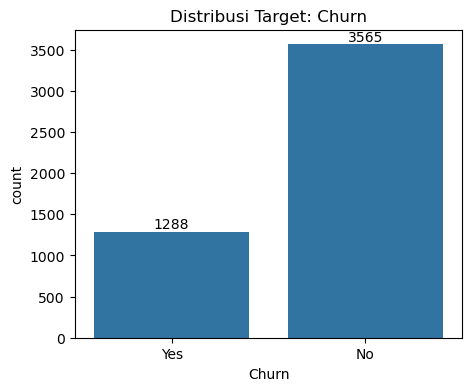

In [29]:
plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x='Churn')
plt.title('Distribusi Target: Churn')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

Distribusi target `Churn` tidak seimbang (imbalanced) — proporsi kelas `No` (73,46%) jauh lebih besar dibanding kelas `Yes` (26,54%). Hal ini perlu diperhatikan pada tahap Data Preparation dan Modeling, misalnya dengan teknik penanganan imbalance (resampling seperti SMOTE, atau `class_weight='balanced'` saat training), serta pemilihan metrik evaluasi yang tepat seperti F1-score/recall, bukan hanya accuracy.

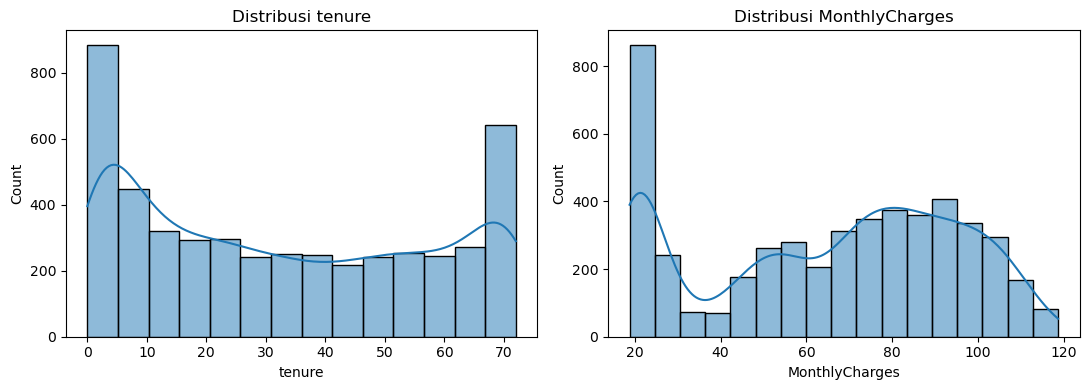

In [30]:
num_cols = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(11,4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

In [31]:
n = len(df)
print(f'tenure < 5           : {(df["tenure"] < 5).sum()} ({(df["tenure"] < 5).mean()*100:.1f}%)')
print(f'tenure > 65          : {(df["tenure"] > 65).sum()} ({(df["tenure"] > 65).mean()*100:.1f}%)')
print(f'MonthlyCharges < 30  : {(df["MonthlyCharges"] < 30).sum()} ({(df["MonthlyCharges"] < 30).mean()*100:.1f}%)')

tenure < 5           : 797 (16.4%)
tenure > 65          : 710 (14.6%)
MonthlyCharges < 30  : 1089 (22.4%)


`tenure` cenderung memiliki distribusi bimodal — konsentrasi tinggi pada pelanggan baru (tenure mendekati <5, sekitar 790 pelanggan) dan pelanggan lama (tenure >65, sekitar 700 pelanggan).

`MonthlyCharges` distribusinya lebih merata, dengan konsentrasi di tagihan rendah (~20), yaitu pelanggan dengan `MonthlyCharges < 30`

In [32]:
cat_cols = ['Dependents','OnlineSecurity','OnlineBackup','InternetService',
            'DeviceProtection','TechSupport','Contract','PaperlessBilling']

def plot_batch(cols):
    fig, axes = plt.subplots(2, 2, figsize=(11,8))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]
        sns.countplot(data=df, x=col, ax=ax, order=df[col].value_counts().index)
        total = len(df)
        for p in ax.patches:
            pct = 100 * p.get_height() / total
            ax.annotate(f'{pct:.1f}%', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)
        ax.set_title(f'Distribusi {col}')
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

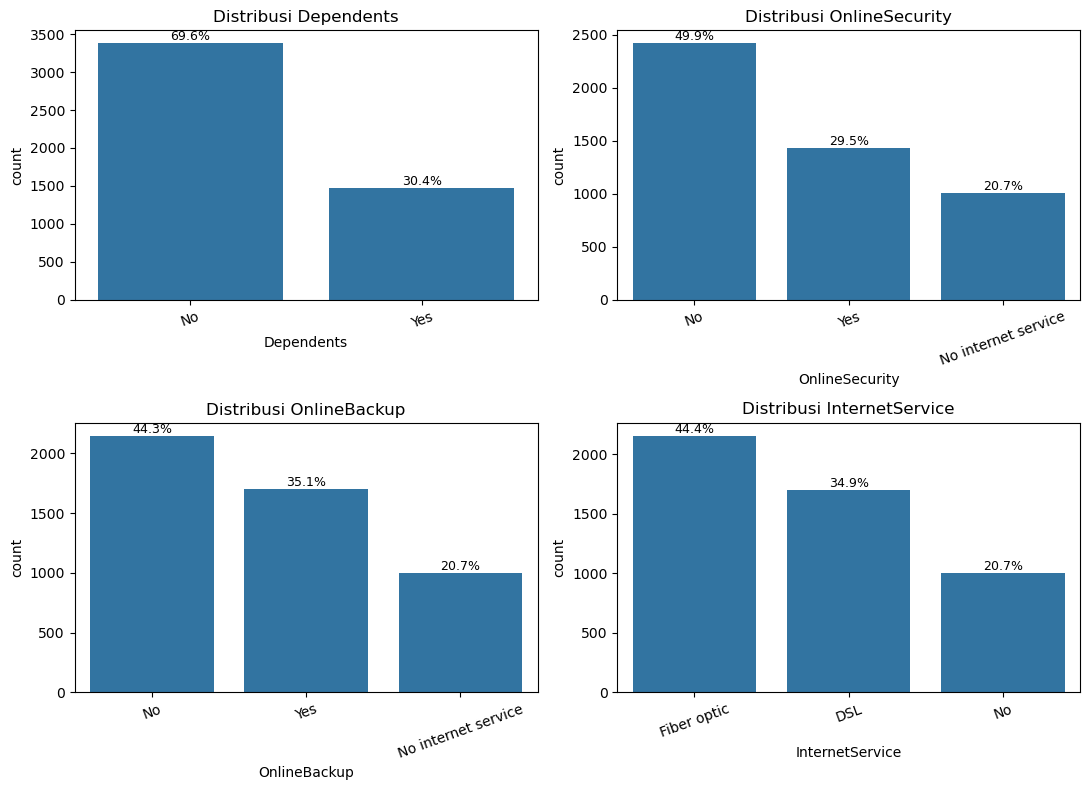

In [33]:
plot_batch(cat_cols[:4])

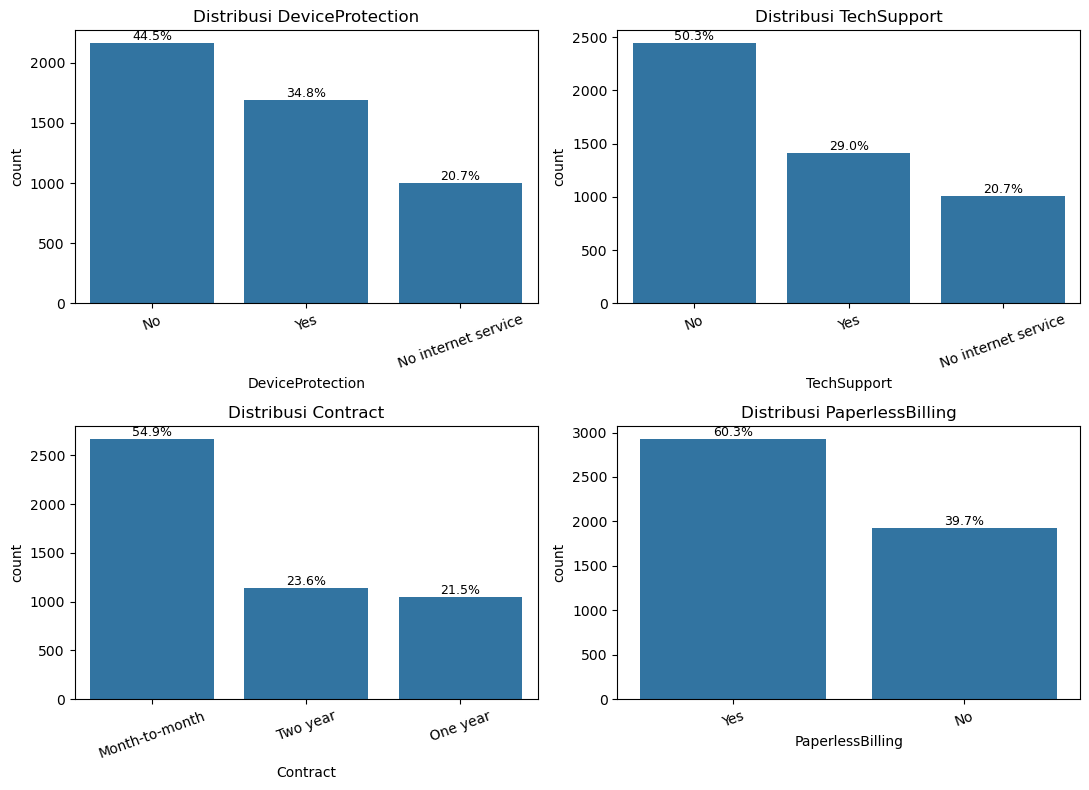

In [34]:
plot_batch(cat_cols[4:])

**Interpretasi:**

- **Dependents**: Didominasi kategori `No` (69,6%), pelanggan dengan tanggungan (`Yes`) hanya 30,4%.

- **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport**: Keempat kolom ini punya pola distribusi yang mirip — mayoritas `No` (44-50%), diikuti `Yes` (29-35%), dan `"No internet service"` konsisten di angka **20,7%** pada keempat kolom.

- **InternetService**: Didominasi `Fiber optic` (44,4%) dan `DSL` (34,9%), sedangkan `No` (tidak berlangganan internet) sebesar **20,7%** — mirip dengan proporsi `"No internet service"` di keempat kolom sebelumnya. Ini mengonfirmasi bahwa kategori `"No internet service"` pada `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, dan `TechSupport` kemungkinan besar adalah turunan langsung dari `InternetService == 'No'`, bukan variasi independen. Akan dilakukan analisis lebih lanjut pada Section 4.3 (Correlation & Multicollinearity Check).

- **Contract**: Didominasi kontrak `Month-to-month` (54,9%), jauh lebih besar dibanding `One year` (21,5%) dan `Two year` (23,6%).

- **PaperlessBilling**: Mayoritas pelanggan menggunakan `PaperlessBilling` (60,3% `Yes` vs 39,7% `No`).

Secara umum, tidak ditemukan kolom dengan distribusi yang terlalu timpang (misalnya >95% di satu kategori), sehingga seluruh fitur kategorikal masih memiliki variasi yang cukup untuk dianalisis lebih lanjut pada tahap bivariate terhadap target `Churn`.

**4.2 Bivariate Analysis (terhadap Target)**

>   *Tujuan:* Mencari pola hubungan antara tiap fitur dengan target, untuk menjawab langsung Problem Statement di Section 1.2.

**Fitur Numerik**

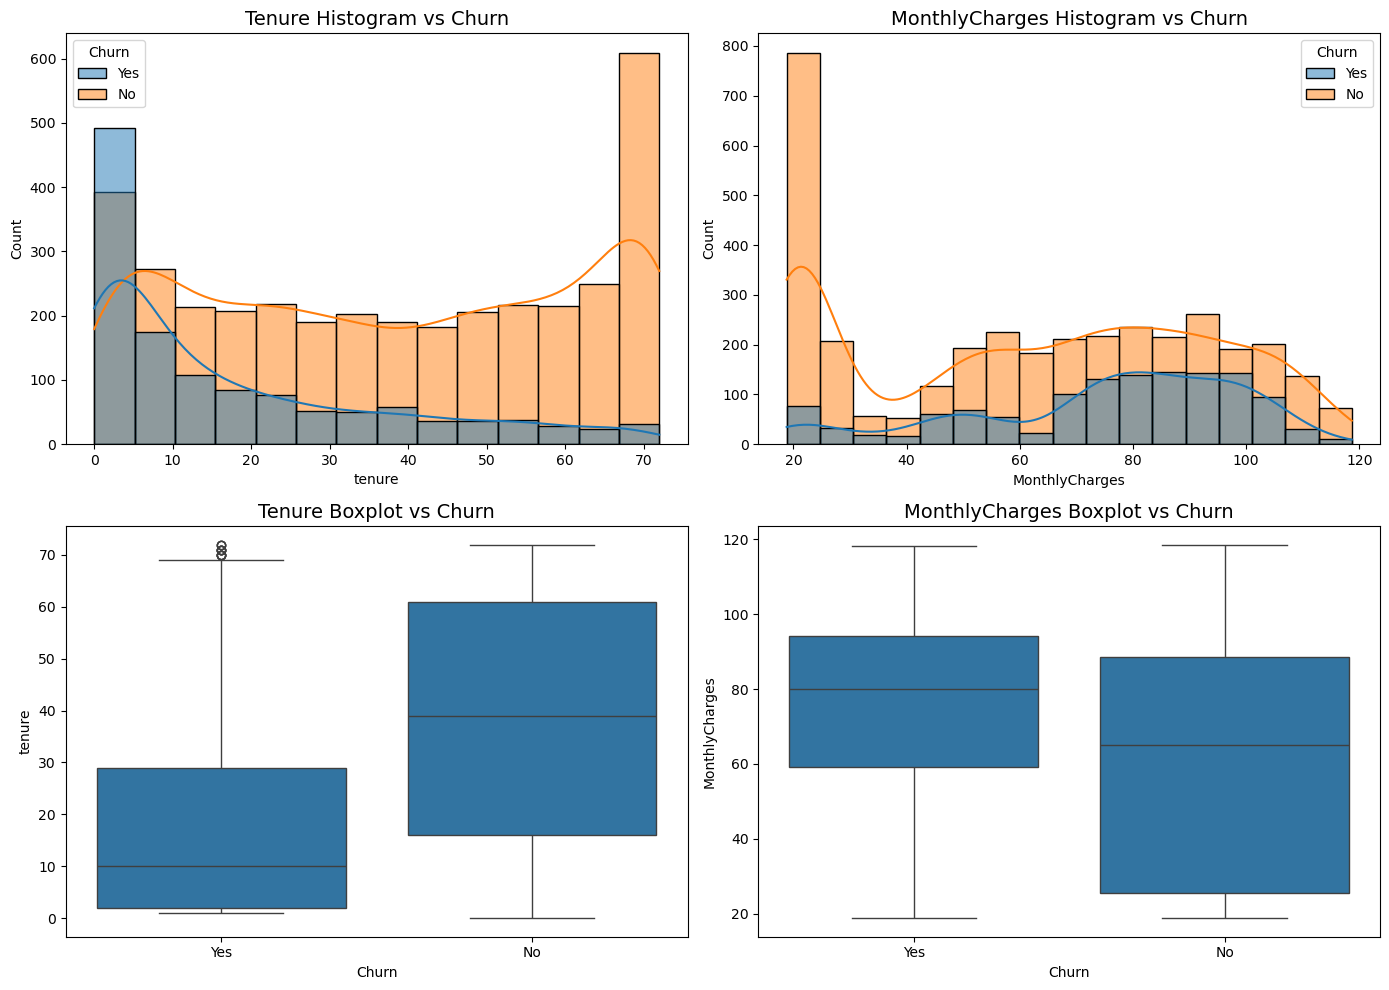

In [35]:
plt.figure(figsize=(14,10))

plt.subplot(221)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)
plt.title('Tenure Histogram vs Churn', fontsize=14)

plt.subplot(222)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title('MonthlyCharges Histogram vs Churn', fontsize=14)

plt.subplot(223)
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure Boxplot vs Churn', fontsize=14)

plt.subplot(224)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges Boxplot vs Churn', fontsize=14)

plt.tight_layout()
plt.show()

**Interpretasi:**

- **Tenure**: Pelanggan yang churn mayoritas memiliki tenure rendah (median 10 bulan), sedangkan yang bertahan memiliki tenure jauh lebih tinggi (median 39 bulan). Terdapat 13 pelanggan churn dengan tenure sangat tinggi (70-72 bulan) yang tampak sebagai outlier pada boxplot grup Churn=Yes — pelanggan loyal bertahun-tahun yang tetap berhenti, berbeda karakter dari mayoritas churn yang terjadi di awal masa langganan.

- **MonthlyCharges**: Pelanggan yang churn cenderung memiliki tagihan bulanan lebih tinggi (median 80) dibanding yang bertahan (median 64.95), dengan konsentrasi churn tertinggi pada rentang tagihan 80-100. Tidak ditemukan outlier pada boxplot MonthlyCharges di kedua kelas Churn.

Secara umum, pelanggan baru dan pelanggan tagihan tinggi menunjukkan risiko churn yang lebih besar dibanding pelanggan lama dan pelanggan tagihan rendah.

**Fitur Kategorik**

In [36]:
def plot_batch(cols):
    fig, axes = plt.subplots(2, 2, figsize=(11,9))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]
        ct = pd.crosstab(df[col], df['Churn'], normalize='index')
        ct = ct.loc[df[col].value_counts().index]
        ct.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'{col} vs Churn')
        ax.set_ylabel('Proporsi')
        ax.tick_params(axis='x', rotation=20)
        ax.legend(title='Churn', fontsize=8)
        for c in ax.containers:
            labels = [f'{v*100:.1f}%' if v>0.03 else '' for v in c.datavalues]
            ax.bar_label(c, labels=labels, label_type='center', fontsize=8)
    plt.tight_layout()
    plt.show()

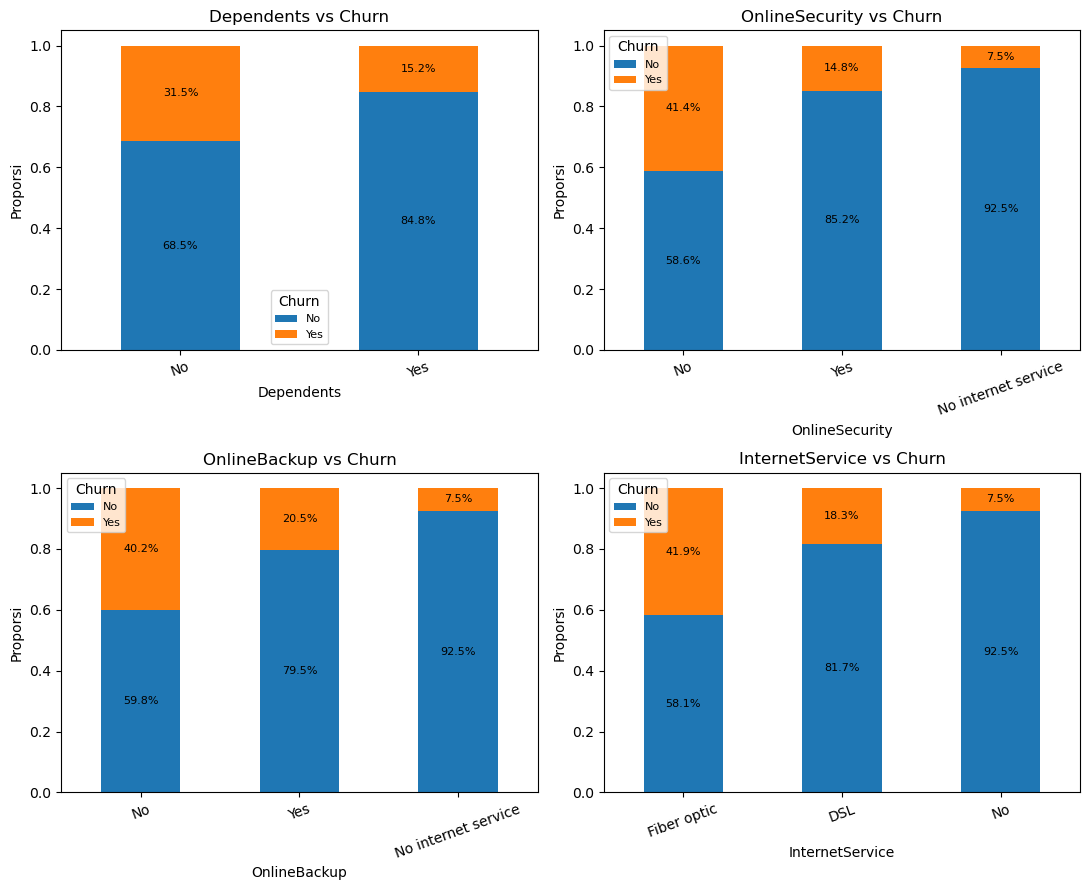

In [37]:
plot_batch(cat_cols[:4])

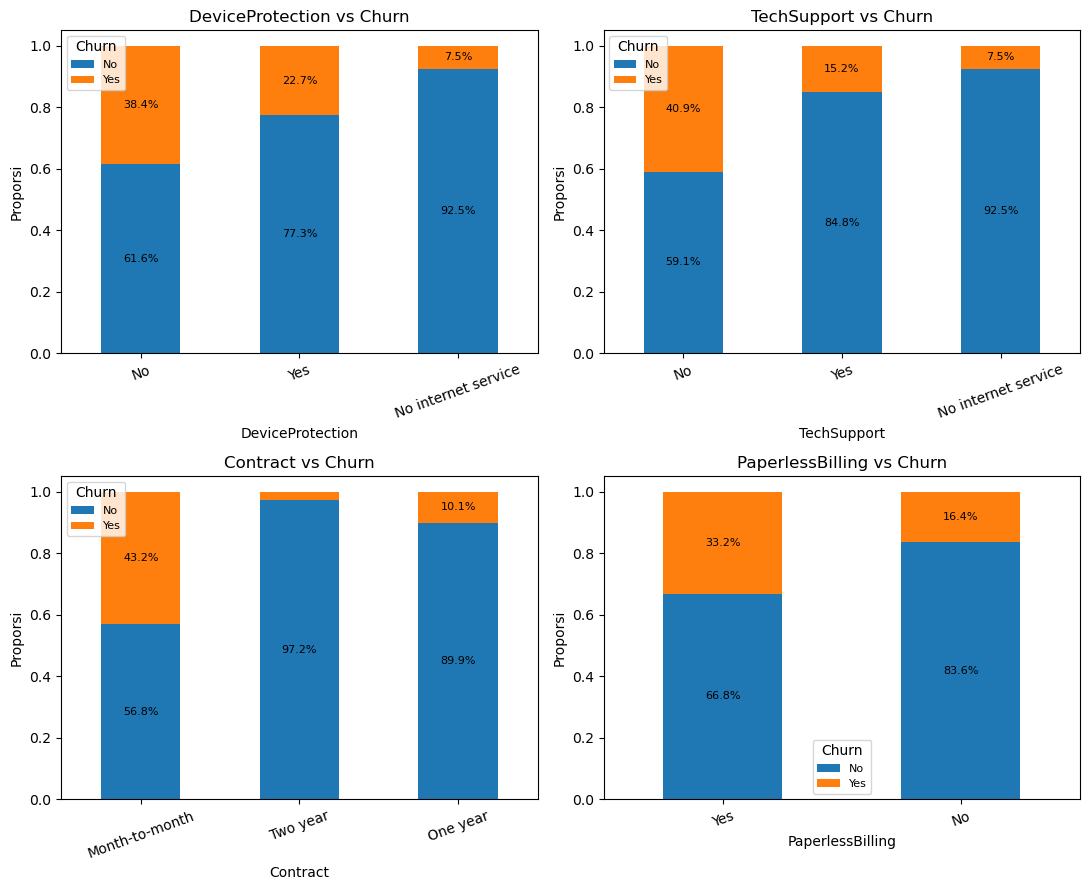

In [38]:
plot_batch(cat_cols[4:])

**Interpretasi:**

Dari 8 fitur kategorikal yang dianalisis terhadap `Churn`, beberapa pola yang paling menonjol:

- **Contract** memberikan perbedaan paling ekstrem — `Month-to-month` (43,2% churn) jauh lebih berisiko dibanding `Two year` (2,8% churn). Ini indikasi kuat bahwa komitmen kontrak jangka panjang menurunkan churn.
- **InternetService** dengan `Fiber optic` (41,9% churn) lebih berisiko dibanding `DSL` (18,3%) dan `No` (7,5%).
- Empat fitur layanan tambahan (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) menunjukkan pola serupa: pelanggan yang **tidak** menggunakan layanan tersebut (`No`) punya churn rate lebih tinggi (38-41%) dibanding yang menggunakan (`Yes`, 15-23%). Kategori `No internet service` konsisten paling rendah (7,5%) di keempatnya — sejalan dengan `InternetService = No`.
- **PaperlessBilling** (`Yes` = 33,2% vs `No` = 16,4%) dan **Dependents** (`No` = 31,5% vs `Yes` = 15,2%) juga menunjukkan perbedaan yang cukup jelas, meski tidak seekstrem `Contract`.

Secara keseluruhan, fitur yang berkaitan dengan **jenis kontrak, jenis layanan internet, dan penggunaan layanan tambahan** tampak paling berkaitan erat dengan kecenderungan churn.

>   Ini bagian paling penting untuk menjawab Problem Statement di Section 1.2 - cari pola antara tiap fitur dengan target, bukan sekadar plot tanpa insight.

**4.3 Correlation & Multicollinearity Check**

>   *Tujuan:* Mengecek hubungan antar fitur untuk mendeteksi multikolinearitas yang bisa mengganggu interpretasi model nanti.

**Fitur Numerik**

In [39]:
num_cols = ['tenure', 'MonthlyCharges']

# Pearson correlation
print('--- Pearson correlation ---')
print(df[num_cols].corr())

--- Pearson correlation ---
                  tenure  MonthlyCharges
tenure          1.000000        0.234126
MonthlyCharges  0.234126        1.000000


In [40]:
# VIF
X = df[num_cols].copy()
X['intercept'] = 1
vif_data = pd.DataFrame()
vif_data['feature'] = num_cols
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(num_cols))]
print(vif_data)

          feature       VIF
0          tenure  1.057994
1  MonthlyCharges  1.057994


**Interpretasi:**

Korelasi Pearson antara `tenure` dan `MonthlyCharges` tergolong lemah (0,23), dan nilai VIF keduanya (1,06), di bawah batas multikolinearitas (VIF > 5). Tidak ditemukan indikasi multikolinearitas pada fitur numerik.

**Fitur Kategorik**

In [41]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    return np.sqrt(phi2 / min(k-1, r-1))

cat_cols = ['Dependents','OnlineSecurity','OnlineBackup','InternetService',
            'DeviceProtection','TechSupport','Contract','PaperlessBilling']

matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

matrix.round(2)

,Dependents,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling
Dependents,1.00,0.19,0.15,0.18,0.14,0.17,0.24,0.11
OnlineSecurity,0.19,1.00,0.72,0.73,0.72,0.73,0.30,0.34
OnlineBackup,0.15,0.72,1.00,0.71,0.72,0.72,0.26,0.31
InternetService,0.18,0.73,0.71,1.00,0.71,0.72,0.21,0.37
DeviceProtection,0.14,0.72,0.72,0.71,1.00,0.73,0.30,0.31
TechSupport,0.17,0.73,0.72,0.72,0.73,1.00,0.33,0.32
Contract,0.24,0.30,0.26,0.21,0.30,0.33,1.00,0.18
PaperlessBilling,0.11,0.34,0.31,0.37,0.31,0.32,0.18,1.00


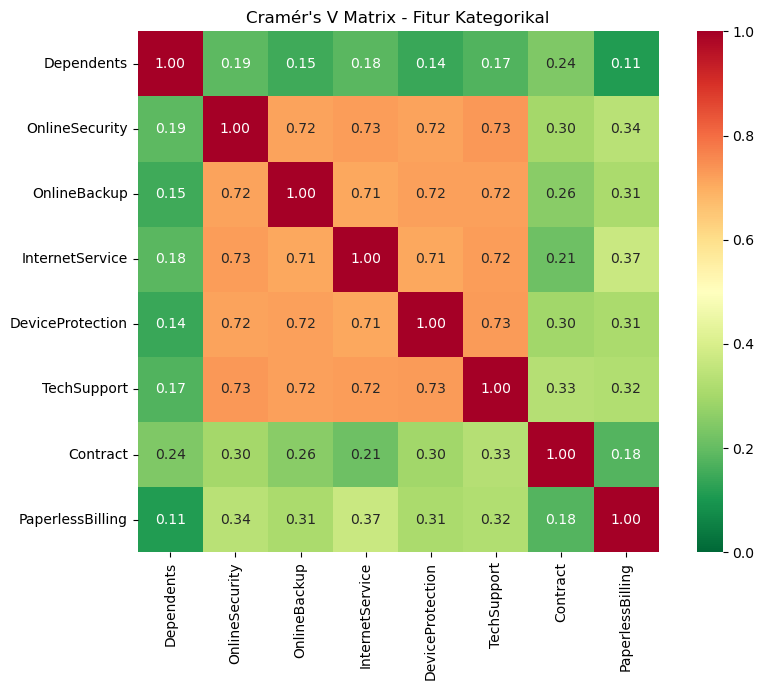

In [42]:
plt.figure(figsize=(9,7))
sns.heatmap(matrix.astype(float), annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=1, square=True)
plt.title("Cramér's V Matrix - Fitur Kategorikal")
plt.tight_layout()
plt.show()

In [43]:
related_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']

for col in related_cols:
    print(f'--- InternetService vs {col} ---')
    print(pd.crosstab(df['InternetService'], df[col]))
    print()

--- InternetService vs OnlineSecurity ---
OnlineSecurity     No  No internet service  Yes
InternetService                                
DSL               856                    0  840
Fiber optic      1564                    0  590
No                  0                 1003    0

--- InternetService vs OnlineBackup ---
OnlineBackup       No  No internet service  Yes
InternetService                                
DSL               922                    0  774
Fiber optic      1226                    0  928
No                  0                 1003    0

--- InternetService vs DeviceProtection ---
DeviceProtection    No  No internet service  Yes
InternetService                                 
DSL                947                    0  749
Fiber optic       1215                    0  939
No                   0                 1003    0

--- InternetService vs TechSupport ---
TechSupport        No  No internet service  Yes
InternetService                                
DSL        

**Interpretasi:**

- Fitur `Dependents`, `Contract`, dan `PaperlessBilling` memiliki korelasi lemah-sedang (0,11-0,37) terhadap fitur lainnya — tidak ada indikasi redundansi.

- Fitur `OnlineSecurity`, `OnlineBackup`, `InternetService`, `DeviceProtection`, dan `TechSupport` memiliki korelasi kuat satu sama lain (0,71-0,73). 
Berdasarkan pengecekan cross-tab, korelasi kuat ini disebabkan oleh kategori `"No internet service"` pada keempat fitur layanan yang selalu identik dengan `InternetService == 'No'` (1.003 baris, cocok 100%). Namun, di luar kategori tersebut (pelanggan dengan `DSL`/`Fiber optic`), nilai `Yes`/`No` pada keempat fitur layanan tetap bervariasi bebas — sehingga korelasinya kuat namun tidak sempurna (bukan 1,00).

Potensi multikolinearitas akan ditangani pada tahap Data Preparation melalui strategi encoding yang tepat (k-1 dummy variable), dan divalidasi ulang menggunakan VIF setelah proses encoding.

**4.4 Multivariate / Interaction Analysis (opsional)**

>   *Tujuan:* Menelusuri interaksi antara beberapa fitur sekaligus untuk pola yang lebih kompleks dari yang bisa ditangkap analisis dua arah.

Dari analisis di Section 4.2, fitur yang paling dapat membedakan pelanggan churn atau tidak adalah `Contract` dan `InternetService`. Pada bagian ini akan dilihat interaksi antara kedua fitur tersebut terhadap churn rate, untuk mengetahui apakah kombinasi keduanya menghasilkan pola yang lebih kompleks dibanding melihat masing-masing fitur secara terpisah.

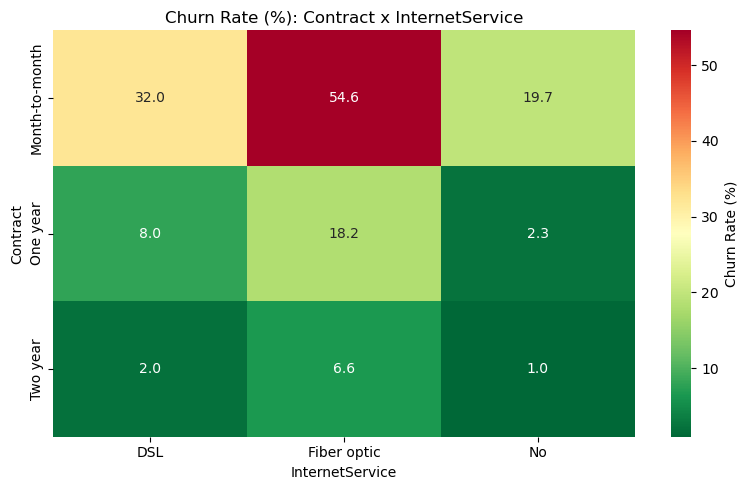

In [44]:
pivot = df.groupby(['Contract','InternetService'])['Churn'].apply(lambda x: (x=='Yes').mean()*100).unstack()

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label':'Churn Rate (%)'})
plt.title('Churn Rate (%): Contract x InternetService')
plt.tight_layout()
plt.show()

**Interpretasi:**

Interaksi antara `Contract` dan `InternetService` menunjukkan efek yang saling memperkuat. Kombinasi `Month-to-month` + `Fiber optic` memiliki churn rate tertinggi (54,6%) — lebih tinggi dibanding masing-masing fitur dilihat secara terpisah. Sebaliknya, kombinasi `Two year` + `No internet` memiliki churn rate terendah (1,0%). Temuan ini mengindikasikan bahwa segmen pelanggan `Fiber optic` dengan kontrak `Month-to-month` merupakan prioritas utama untuk strategi retensi pelanggan.

## **Section 5. Data Preparation**

>   *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan (numerik, terskala, tanpa kategori yang belum di-encode).

**5.1 Initialization**
- Initialization function
- Define Feature and Target

>   *Tujuan:* Menyiapkan fungsi bantu dan mendefinisikan mana kolom fitur (X) dan target (y) sebelum transformasi dimulai.

In [45]:
X = df.drop(columns=['Churn'])
y = df['Churn']

Churn
No     0.734597
Yes    0.265403
Name: proportion, dtype: float64


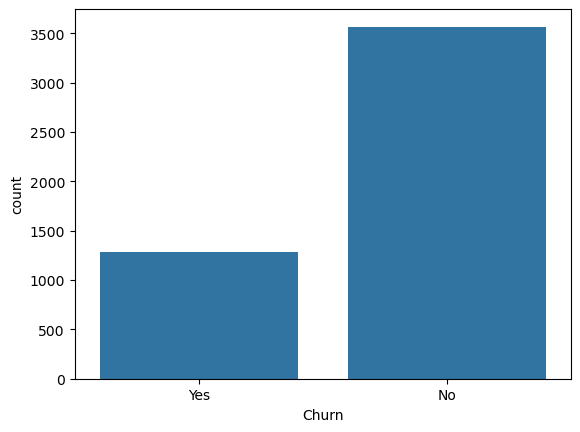

In [46]:
print(df["Churn"].value_counts(normalize=True))
sns.countplot(x=df["Churn"])
plt.show()

**5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

>   *Tujuan:* Membagi data `Seen` menjadi training dan testing untuk keperluan pengembangan dan evaluasi model.

In [47]:
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size= 0.2,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

x_train.reset_index(inplace=True , drop=True)
x_test.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

print( f"feature (train) shape: {x_train.shape}")
print( f"target (train) shape: {y_train.shape}")

feature (train) shape: (3882, 10)
target (train) shape: (3882,)


**5.3 Handling Imbalanced Data (jika relevan)**

>   *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

>   Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling - **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

Churn
No     0.734673
Yes    0.265327
Name: proportion, dtype: float64


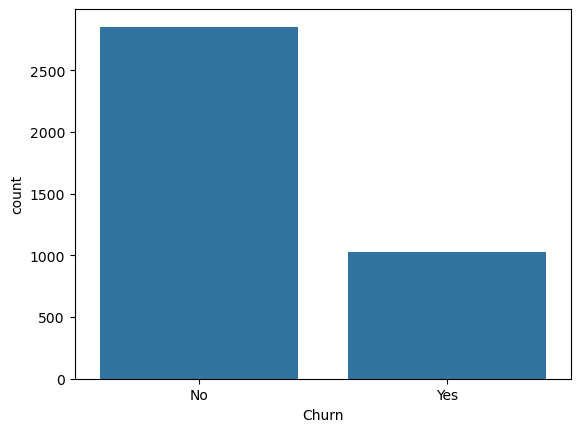

In [48]:
#cek imbalanced data train
print(y_train.value_counts(normalize=True))
sns.countplot(x=y_train)
plt.show()

**Interpretasi:**

Proporsi target pada data training adalah 73,47% (`No`) : 26,53% (`Yes`)

Strategi Imbalanced:
- Strategi pertama yang digunakan adalah `class_weight='balanced'`, yang akan diterapkan langsung pada model saat inisialisasi di Section 6 — tanpa mengubah data training.
- Sebagai pembanding, akan dicoba juga beberapa teknik resampling (SMOTE, RandomOverSampler, RandomUnderSampler) yang dimasukkan sebagai step dalam Pipeline (menggunakan `imblearn.pipeline.Pipeline`), untuk melihat apakah performa model dapat ditingkatkan lebih lanjut dibanding hanya menggunakan `class_weight`.
- Resampling hanya akan diterapkan pada data training di setiap fold cross-validation, tidak dilakukan pada data testing/unseen, untuk menghindari leakage

**5.4 Data Transformation (Feature Engineering)**

>   *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

**Encoding**

 Dilakukan encoding untuk fitur-fitur kategorikal yang dimiliki. Seluruh 8 fitur kategorikal (`Dependents`, `OnlineSecurity`, `OnlineBackup`, `InternetService`, `DeviceProtection`, `TechSupport`, `Contract`, `PaperlessBilling`) akan di-encode menggunakan **One-Hot Encoding**, dengan pertimbangan:

- Seluruh fitur bersifat **nominal** (tidak memiliki urutan), sehingga tidak cocok menggunakan Ordinal Encoding.
- Cardinality tiap fitur tergolong **rendah** (2-3 kategori unik, hasil pengecekan Section 3.4), sehingga One-Hot Encoding tidak akan menghasilkan terlalu banyak kolom baru
- Digunakan parameter `drop='first'` untuk mengambil k-1 kategori dari setiap fitur, guna menghindari dummy variable trap (multikolinearitas sempurna antar kolom dummy dalam 1 fitur yang sama).

In [49]:
cat_cols = ['Dependents','OnlineSecurity','OnlineBackup','InternetService',
            'DeviceProtection','TechSupport','Contract','PaperlessBilling']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(x_train[cat_cols])

ohe_feature_train = pd.DataFrame(ohe.transform(x_train[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
ohe_feature_test = pd.DataFrame(ohe.transform(x_test[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))

print('Shape sebelum encoding:', x_train[cat_cols].shape)
print('Shape setelah encoding:', ohe_feature_train.shape)
ohe_feature_train.head()

Shape sebelum encoding: (3882, 8)
Shape setelah encoding: (3882, 14)


,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,InternetService_Fiber optic,InternetService_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


**Scaling**

Scaling pada fitur numerik `tenure` dan `MonthlyCharges` dengan menggunakan StandardScaler

In [50]:
num_cols = ['tenure', 'MonthlyCharges']

scaler = StandardScaler()
scaler.fit(x_train[num_cols])

numeric_scaled_train = pd.DataFrame(scaler.transform(x_train[num_cols]), columns=num_cols)
numeric_scaled_test = pd.DataFrame(scaler.transform(x_test[num_cols]), columns=num_cols)

print('Sebelum scaling:')
print(x_train[num_cols].describe().round(2))
print()
print('Setelah scaling:')
print(numeric_scaled_train.describe().round(2))

Sebelum scaling:
       tenure  MonthlyCharges
count  3882.0         3882.00
mean     32.7           65.71
std      24.5           29.82
min       0.0           18.80
25%       9.0           40.55
50%      29.0           70.85
75%      56.0           90.40
max      72.0          118.65

Setelah scaling:
        tenure  MonthlyCharges
count  3882.00         3882.00
mean      0.00            0.00
std       1.00            1.00
min      -1.34           -1.57
25%      -0.97           -0.84
50%      -0.15            0.17
75%       0.95            0.83
max       1.60            1.78


**Binning**

Binning pada fitur numerik `tenure` dan `MonthlyCharges`, untuk menangkap **hubungan non-linear** antara fitur dengan target — pola yang mungkin tidak tertangkap optimal oleh model linear seperti Logistic Regression.
Dari section 4.2, distribusi `MonthlyCharges`, menunjukkan pola non-monoton (naik-turun) terhadap churn rate, `tenure` menunjukkan pola yang relatif monoton menurun, namun distribusinya bimodal dengan konsentrasi tinggi pada pelanggan baru dan pelanggan lama.

In [51]:
# tenure
binning_tenure = KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal')
binning_tenure.fit(x_train[['tenure']])

tenure_bin_train = pd.DataFrame(binning_tenure.transform(x_train[['tenure']]), columns=['tenure_bin'])
tenure_bin_test = pd.DataFrame(binning_tenure.transform(x_test[['tenure']]), columns=['tenure_bin'])

# MonthlyCharges
binning_charge = KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal')
binning_charge.fit(x_train[['MonthlyCharges']])

charge_bin_train = pd.DataFrame(binning_charge.transform(x_train[['MonthlyCharges']]), columns=['charge_bin'])
charge_bin_test = pd.DataFrame(binning_charge.transform(x_test[['MonthlyCharges']]), columns=['charge_bin'])

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


**Fitur Gabungan**

Berdasarkan analisis section 4.4, gabungan antara `Contract` dan `InternetService` memiliki churn rate yang tinggi dibandingkan fitur secara terpisah. Dapat dipertimbangkan untuk membuat fitur gabungan.

**5.5 Feature Selection**

>   *Tujuan:* Memilih fitur yang paling relevan/berkontribusi untuk mengurangi noise dan risiko overfitting.

In [52]:
#menggabungkan semua data dari fitur engineering
# combine all data
x_train_pre = pd.concat(
    objs=[
        numeric_scaled_train,
        ohe_feature_train,
        tenure_bin_train,
        charge_bin_train,
    ],
    axis=1
)

x_test_pre = pd.concat(
    objs=[
        numeric_scaled_test,
        ohe_feature_test,
        tenure_bin_test,
        charge_bin_test,
    ],
    axis=1
)

print('Shape x_train_pre:', x_train_pre.shape)
print('Shape x_test_pre :', x_test_pre.shape)
x_train_pre.head()

Shape x_train_pre: (3882, 18)
Shape x_test_pre : (971, 18)


,tenure,MonthlyCharges,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,InternetService_Fiber optic,InternetService_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,tenure_bin,charge_bin
0,-1.090115,-0.335575,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.543054,1.255921,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,3.0
2,0.910517,-1.522909,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0
3,-0.477677,-0.996323,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,-1.212603,0.128961,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Univariate

In [53]:
select = SelectFpr(alpha=0.05)
select.fit(x_train_pre, y_train)

pval_report = pd.DataFrame({
    'features': select.feature_names_in_,
    'pvalue': select.pvalues_
})
pval_report['alpha'] = 0.05
pval_report['status(<alpha)'] = pval_report['pvalue'] < 0.05
pval_report.sort_values('pvalue')

,features,pvalue,alpha,status(<alpha)
16,tenure_bin,3.319458e-123,0.05,True
0,tenure,1.103067e-122,0.05,True
7,InternetService_Fiber optic,2.785710e-83,0.05,True
14,Contract_Two year,3.949223e-81,0.05,True
11,TechSupport_No internet service,1.198136e-42,0.05,True
9,DeviceProtection_No internet service,1.198136e-42,0.05,True
8,InternetService_No,1.198136e-42,0.05,True
5,OnlineBackup_No internet service,1.198136e-42,0.05,True
3,OnlineSecurity_No internet service,1.198136e-42,0.05,True
17,charge_bin,4.643786e-34,0.05,True


Seluruh 18 fitur menunjukkan hubungan yang signifikan secara statistik terhadap `Churn` (p-value < 0,05)

In [54]:
skb = SelectKBest(score_func=f_classif, k=10)
skb.fit(x_train_pre, y_train)   # x_train_pre hasil Section 5.4

kbest_report = pd.DataFrame({
    'features': x_train_pre.columns,
    'score': skb.scores_,
    'selected(k=10)': skb.get_support()
}).sort_values('score', ascending=False)

kbest_report

,features,score,selected(k=10)
16,tenure_bin,599.344303,True
0,tenure,596.577014,True
7,InternetService_Fiber optic,392.450489,True
14,Contract_Two year,381.581726,True
11,TechSupport_No internet service,191.983106,True
8,InternetService_No,191.983106,True
9,DeviceProtection_No internet service,191.983106,True
5,OnlineBackup_No internet service,191.983106,True
3,OnlineSecurity_No internet service,191.983106,True
17,charge_bin,150.922677,True


fitur selection menggunakan SelectFpr

**5.6 Overview**

>   *Tujuan:* Merangkum hasil akhir data preparation (bentuk data final) sebelum masuk ke tahap Model Development.

In [55]:
print('=== Shape ===')
print('x_train_pre:', x_train_pre.shape)
print('x_test_pre :', x_test_pre.shape)
print('y_train    :', y_train.shape)
print('y_test     :', y_test.shape)
print()

print('=== Proporsi target ===')
print('y_train:', y_train.value_counts(normalize=True).round(4).to_dict())
print('y_test :', y_test.value_counts(normalize=True).round(4).to_dict())
print()

print('=== Cek missing value ===')
print('x_train_pre:', x_train_pre.isnull().sum().sum())
print('x_test_pre :', x_test_pre.isnull().sum().sum())

=== Shape ===
x_train_pre: (3882, 18)
x_test_pre : (971, 18)
y_train    : (3882,)
y_test     : (971,)

=== Proporsi target ===
y_train: {'No': 0.7347, 'Yes': 0.2653}
y_test : {'No': 0.7343, 'Yes': 0.2657}

=== Cek missing value ===
x_train_pre: 0
x_test_pre : 0


In [56]:
x_train_pre.head()

,tenure,MonthlyCharges,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,InternetService_Fiber optic,InternetService_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,tenure_bin,charge_bin
0,-1.090115,-0.335575,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.543054,1.255921,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,3.0
2,0.910517,-1.522909,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0
3,-0.477677,-0.996323,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,-1.212603,0.128961,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## **Section 6. Model Development**

>   *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning menggunakan data.

**6.1 Initialization**
- Initialization Function
- Create Custom Metrics
- Define Cross-Validation Strategy
- Create a workflow of the experiment

>   *Tujuan:* Menyiapkan fungsi metrik custom dan strategi cross-validation yang dipakai konsisten di seluruh eksperimen model.

>   Tentukan strategi CV secara eksplisit (misal `StratifiedKFold` untuk klasifikasi dengan target tidak seimbang) dan simpan `RANDOM_STATE` yang sama dari Section 0. Ingat prinsip **CV-first**: bandingkan model lewat cross-validation dulu, baru evaluasi akhir di data testing - jangan sebaliknya.

In [57]:
#encode label target
# 1. Encode target jadi numerik (0/1)
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [58]:
# 2. Create Custom Metrics
scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

In [59]:
def benchmark_models(pipeline, list_model, x_train, y_train, scoring, cv=5, random_state=None):
    skf = StratifiedKFold(n_splits=cv, shuffle=random_state is not None, random_state=random_state)
    all_results = []
    for name, model in list_model.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(classifier, x_train, y_train, cv=skf, scoring=scoring, return_train_score=True)
        row = {'name': name}
        for metric in scoring.keys():
            row[f'train_{metric}'] = np.mean(cv_result[f'train_{metric}'])
            row[f'test_{metric}'] = np.mean(cv_result[f'test_{metric}'])
            row[f'test_{metric}_std'] = np.std(cv_result[f'test_{metric}'])
        all_results.append(row)
    result_df = pd.DataFrame(all_results).sort_values('test_recall', ascending=False).reset_index(drop=True)
    return result_df

In [60]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

**6.2 Developing the Model Pipeline**

>   *Tujuan:* Merangkai seluruh langkah preprocessing dan model ke dalam satu objek Pipeline yang konsisten dipakai ulang.

>   Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold - ini mencegah data leakage antara fold CV.

In [61]:
cat_cols = ['Dependents','OnlineSecurity','OnlineBackup','InternetService','DeviceProtection','TechSupport','Contract','PaperlessBilling']
num_cols = ['tenure', 'MonthlyCharges']

# 1. Preprocessor (gabungan encoding + scaling + binning)
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num_scale', StandardScaler(), num_cols),
    ('num_bin', KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal'), num_cols)
], remainder='drop')

In [62]:
# Pipeline untuk class_weight (tanpa resampling)
pipeline_classweight = Pipeline([
    ('preprocess', preprocessor),
    ('feature_selection', SelectFpr(alpha=0.05)),
    ('classifier', None)
])

In [63]:
from sklearn import set_config
set_config(display='diagram')

# tampilkan bagan visual (Jupyter otomatis render sebagai HTML diagram)
pipeline_classweight

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
# Pipeline untuk resampling (SMOTE)
pipeline_smote = ImbPipeline([
    ('preprocess', preprocessor),
    ('feature_selection', SelectFpr(alpha=0.05)),
    ('resampling', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', None)
])

In [65]:
pipeline_smote

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
# Pipeline untuk resampling (RandomOverSampler)
pipeline_ros = ImbPipeline([
    ('preprocess', preprocessor),
    ('feature_selection', SelectFpr(alpha=0.05)),
    ('resampling', RandomOverSampler(random_state=RANDOM_STATE)),
    ('classifier', None)
])

In [67]:
pipeline_ros

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**6.3 Model Benchmarking (Comparing model base performance)**

>   *Tujuan:* Membandingkan performa dasar beberapa algoritma (tanpa tuning) untuk memilih kandidat terbaik yang layak dituning lebih lanjut.

In [68]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()  # untuk XGBoost, setara class_weight

# List model UNTUK pipeline_classweight (cuma yang support class_weight/setara)
list_model_cw = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
}

# List model UNTUK pipeline_smote & pipeline_ros (SEMUA 9 model, parameter default tanpa class_weight)
list_model_resampling = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Bagging': BaggingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
}

Model Benchmarking dengan class_weight

In [69]:
result_cw = benchmark_models(pipeline_classweight, list_model_cw, x_train, y_train, scoring, cv=5, random_state=RANDOM_STATE)
result_cw

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear'

,name,train_recall,test_recall,test_recall_std,train_precision,test_precision,test_precision_std,train_roc_auc,test_roc_auc,test_roc_auc_std
0,Logistic Regression,0.797816,0.797087,0.026124,0.507118,0.507771,0.012167,0.843694,0.840232,0.010839
1,LightGBM,0.976942,0.718447,0.041305,0.683581,0.528430,0.005239,0.954834,0.828352,0.017019
2,XGBoost,0.997816,0.652427,0.028239,0.794108,0.539629,0.022291,0.987528,0.816855,0.015162
3,Decision Tree,1.000000,0.458252,0.031995,0.987552,0.477981,0.035255,0.999968,0.638567,0.019371
4,Random Forest,0.999515,0.447573,0.029671,0.987777,0.575839,0.018466,0.999762,0.803590,0.009651


Model Benchmark dengan SMOTE

In [70]:
result_smote = benchmark_models(pipeline_smote, list_model_resampling, x_train, y_train, scoring, cv=5, random_state=RANDOM_STATE)
result_smote

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear'

,name,train_recall,test_recall,test_recall_std,train_precision,test_precision,test_precision_std,train_roc_auc,test_roc_auc,test_roc_auc_std
0,Logistic Regression,0.793932,0.788350,0.025055,0.507562,0.505474,0.011814,0.843187,0.839271,0.011733
1,AdaBoost,0.789320,0.782524,0.025943,0.520474,0.515162,0.013805,0.847757,0.837178,0.013863
2,Gradient Boosting,0.756311,0.706796,0.030794,0.594369,0.555813,0.010785,0.874830,0.840913,0.016127
3,KNN,0.898301,0.693204,0.029191,0.602708,0.460743,0.004574,0.931674,0.762742,0.011543
4,LightGBM,0.838107,0.628155,0.049372,0.735867,0.571346,0.025512,0.948095,0.824810,0.023062
5,XGBoost,0.893932,0.584466,0.039628,0.818476,0.555351,0.036442,0.974942,0.813692,0.018114
6,Decision Tree,0.987379,0.540777,0.042275,1.000000,0.488130,0.020035,0.999968,0.668879,0.019158
7,Random Forest,0.997087,0.539806,0.044850,0.990375,0.554370,0.024451,0.999961,0.804342,0.014729
8,Bagging,0.962379,0.533981,0.037976,0.974495,0.542751,0.029858,0.998507,0.778377,0.016879


Model Benchmark dengan Random Over Sampler

In [71]:
result_ros = benchmark_models(pipeline_ros, list_model_resampling, x_train, y_train, scoring, cv=5, random_state=RANDOM_STATE)
result_ros

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear'

,name,train_recall,test_recall,test_recall_std,train_precision,test_precision,test_precision_std,train_roc_auc,test_roc_auc,test_roc_auc_std
0,AdaBoost,0.804126,0.797087,0.021359,0.515889,0.513943,0.017652,0.847304,0.835610,0.013294
1,Logistic Regression,0.796845,0.792233,0.025392,0.509340,0.507494,0.010763,0.843201,0.839745,0.010902
2,Gradient Boosting,0.841990,0.780583,0.028372,0.560240,0.528957,0.007879,0.886308,0.841786,0.014445
3,LightGBM,0.936650,0.688350,0.043354,0.694084,0.532732,0.021019,0.955159,0.823475,0.019096
4,KNN,0.894903,0.686408,0.037926,0.584608,0.441760,0.010309,0.930389,0.753304,0.014754
5,XGBoost,0.968689,0.633010,0.030331,0.802243,0.539910,0.022502,0.983985,0.814965,0.015628
6,Random Forest,0.998786,0.517476,0.033435,0.988481,0.545731,0.021569,0.999802,0.797157,0.009996
7,Bagging,0.987379,0.493204,0.022477,0.973974,0.524822,0.014888,0.999258,0.769112,0.014429
8,Decision Tree,0.996602,0.492233,0.035883,0.990833,0.491411,0.006856,0.999968,0.654496,0.014166


**6.4 Tune Model**

>   *Tujuan:* Mengoptimalkan hyperparameter dari model kandidat terbaik hasil benchmarking untuk meningkatkan performa.

Tuning Logistic Regression class weight

In [72]:
# 1. Clone dulu supaya pipeline_classweight asli nggak ikut berubah
pipeline_lr = clone(pipeline_classweight)

# 2. Set classifier-nya eksplisit ke Logistic Regression (WAJIB, clone() saja tidak cukup)
pipeline_lr.set_params(classifier=LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,   
    param_grid=param_grid_lr,
    scoring='recall',
    cv=cv_strategy,
    return_train_score=True,
    n_jobs=-1
)
grid_lr.fit(x_train, y_train)

print('Best params:', grid_lr.best_params_)
print('Best CV recall:', round(grid_lr.best_score_, 4))

Best params: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV recall: 0.7981


c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Tuning Adaboost Random Over Sampling

In [74]:
pipeline_ada_recall = clone(pipeline_ros)
pipeline_ada_recall.set_params(classifier=AdaBoostClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
param_grid_ada = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'classifier__estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2), DecisionTreeClassifier(max_depth=3)]
}

grid_ada_recall = GridSearchCV(
    estimator=pipeline_ada_recall,
    param_grid=param_grid_ada,
    scoring='recall',
    cv=cv_strategy,
    return_train_score=True,
    n_jobs=-1
)
grid_ada_recall.fit(x_train, y_train)

print('Best params:', grid_ada_recall.best_params_)
print('Best CV recall:', round(grid_ada_recall.best_score_, 4))

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Best params: {'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__learning_rate': 0.01, 'classifier__n_estimators': 100}
Best CV recall: 0.9515


Tuning Gradient Boosting Random Over Sampling

In [76]:
pipeline_gb_recall = clone(pipeline_ros)
pipeline_gb_recall.set_params(classifier=GradientBoostingClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
param_grid_gb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [2, 3, 4]
}

grid_gb_recall = GridSearchCV(
    estimator=pipeline_gb_recall,
    param_grid=param_grid_gb,
    scoring='recall',
    cv=cv_strategy,
    return_train_score=True,
    n_jobs=-1
)
grid_gb_recall.fit(x_train, y_train)

print('Best params:', grid_gb_recall.best_params_)
print('Best CV recall:', round(grid_gb_recall.best_score_, 4))

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Best params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__n_estimators': 50}
Best CV recall: 0.8495


scoring menggunakan F2 Score : F2 Score adalah salah satu variasi dari F-Measure yang menggabungkan nilai Precision dan Recall, dengan memberikan bobot lebih besar pada Recall dibandingkan Precision. Pada F2 Score (β = 2), Recall dianggap dua kali lebih penting daripada Precision.
F2 Score merupakan metrik evaluasi yang menggabungkan Precision dan Recall, dengan memberikan penekanan lebih besar pada Recall (Recall dua kali lebih penting daripada Precision).

In [78]:
f2_scorer = make_scorer(fbeta_score, beta=2)

Tuning Logistic Regression class weight F2 score

In [79]:
pipeline_lr_f2 = clone(pipeline_classweight)
pipeline_lr_f2.set_params(classifier=LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [80]:
grid_lr_f2 = GridSearchCV(
    estimator=pipeline_lr_f2, param_grid=param_grid_lr, scoring=f2_scorer,
    cv=cv_strategy, return_train_score=True, n_jobs=-1
)
grid_lr_f2.fit(x_train, y_train)
print('LR (F2) - Best params:', grid_lr_f2.best_params_)
print('LR (F2) - Best CV F2-score:', round(grid_lr_f2.best_score_, 4))

LR (F2) - Best params: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
LR (F2) - Best CV F2-score: 0.7159


c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Tuning Adaboost Random Over Sampling F2 score

In [81]:
pipeline_ada_f2 = clone(pipeline_ros)
pipeline_ada_f2.set_params(classifier=AdaBoostClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
grid_ada_f2 = GridSearchCV(
    estimator=pipeline_ada_f2, param_grid=param_grid_ada, scoring=f2_scorer,
    cv=cv_strategy, return_train_score=True, n_jobs=-1
)
grid_ada_f2.fit(x_train, y_train)
print('AdaBoost (F2) - Best params:', grid_ada_f2.best_params_)
print('AdaBoost (F2) - Best CV F2-score:', round(grid_ada_f2.best_score_, 4))

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


AdaBoost (F2) - Best params: {'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100}
AdaBoost (F2) - Best CV F2-score: 0.7377


Tuning Gradient Boosting Random Over Sampling F2 Score

In [83]:
pipeline_gb_f2 = clone(pipeline_ros)
pipeline_gb_f2.set_params(classifier=GradientBoostingClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
grid_gb_f2 = GridSearchCV(
    estimator=pipeline_gb_f2, param_grid=param_grid_gb, scoring=f2_scorer,
    cv=cv_strategy, return_train_score=True, n_jobs=-1
)
grid_gb_f2.fit(x_train, y_train)
print('GB (F2) - Best params:', grid_gb_f2.best_params_)
print('GB (F2) - Best CV F2-score:', round(grid_gb_f2.best_score_, 4))

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


GB (F2) - Best params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
GB (F2) - Best CV F2-score: 0.7327


In [85]:
tuning_recall = {'Logistic Regression': grid_lr, 'AdaBoost': grid_ada_recall, 'Gradient Boosting': grid_gb_recall}
tuning_f2 = {'Logistic Regression': grid_lr_f2, 'AdaBoost': grid_ada_f2, 'Gradient Boosting': grid_gb_f2}

summary_recall = pd.DataFrame([{'model': n, 'best_recall': g.best_score_, 'best_params': g.best_params_} for n, g in tuning_recall.items()])
summary_f2 = pd.DataFrame([{'model': n, 'best_f2': g.best_score_, 'best_params': g.best_params_} for n, g in tuning_f2.items()])

In [86]:
pd.set_option('display.max_colwidth', None)

In [87]:
summary_recall

,model,best_recall,best_params
0,Logistic Regression,0.798058,"{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}"
1,AdaBoost,0.951456,"{'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__learning_rate': 0.01, 'classifier__n_estimators': 100}"
2,Gradient Boosting,0.849515,"{'classifier__learning_rate': 0.01, 'classifier__max_depth': 2, 'classifier__n_estimators': 50}"


In [88]:
summary_f2


,model,best_f2,best_params
0,Logistic Regression,0.715944,"{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}"
1,AdaBoost,0.737748,"{'classifier__estimator': DecisionTreeClassifier(max_depth=1), 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100}"
2,Gradient Boosting,0.732730,"{'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}"


**Catatan:** Meskipun metrik keberhasilan bisnis (Section 1.5-1.6) berfokus pada Recall, Precision, dan ROC-AUC, proses hyperparameter tuning menggunakan F2-score sebagai objective function. F2-score menyeimbangkan recall dan precision, mencegah GridSearchCV menemukan kombinasi ekstrem yang memaksimalkan recall dengan mengorbankan precision secara drastis. Evaluasi final model tetap dilaporkan menggunakan Recall, Precision, dan ROC-AUC sesuai Success Criteria.

**6.5 Analyze Model**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)
- Learning Curve Inspection

>   *Tujuan:* Mengevaluasi performa model secara mendalam di luar satu angka metrik utama, termasuk mengecek tanda overfitting/underfitting.

Evaluate model on data testing

In [89]:
# final model: AdaBoost dengan hyperparameter terbaik (versi F2)
final_model = clone(pipeline_ros)
final_model.set_params(classifier=AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    learning_rate=0.1,
    n_estimators=100,
    random_state=RANDOM_STATE
))

,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
# fit ke SELURUH x_train
final_model.fit(x_train, y_train)

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,steps,"[('preprocess', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_scale', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
# evaluasi ke x_train
y_pred_train = final_model.predict(x_train)
y_proba_train = final_model.predict_proba(x_train)[:,1]

print('Recall (train)   :', round(recall_score(y_train, y_pred_train), 4))
print('Precision (train):', round(precision_score(y_train, y_pred_train), 4))
print('ROC-AUC (train)  :', round(roc_auc_score(y_train, y_proba_train), 4))

Recall (train)   : 0.8437
Precision (train): 0.4825
ROC-AUC (train)  : 0.8394


In [92]:
# evaluasi ke x_test
y_pred = final_model.predict(x_test)
y_proba = final_model.predict_proba(x_test)[:,1]

In [93]:
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

Recall   : 0.8566
Precision: 0.4911
ROC-AUC  : 0.8324


In [94]:
f2_train = fbeta_score(y_train, y_pred_train, beta=2)
f2_test = fbeta_score(y_test, y_pred, beta=2)

print('F2-score (train):', round(f2_train, 4))
print('F2-score (test) :', round(f2_test, 4))

F2-score (train): 0.7338
F2-score (test) : 0.7456


**Interpretasi:**

Recall pada data train (0,8437) dan test (0,8566) menunjukkan hasil yang stabil dengan selisih kecil (<2%), mengindikasikan model **tidak overfitting** dan generalisasi dengan baik ke data baru.

Precision (0,4911) menunjukkan bahwa dari seluruh pelanggan yang diprediksi akan churn, sekitar **51% merupakan false positive** (pelanggan yang diprediksi churn namun sebenarnya tidak churn). Efek dari precision karena prioritas bisnis untuk memaksimalkan deteksi pelanggan churn (recall), meski berdampak pada meningkatnya jumlah pelanggan yang menerima program retensi secara tidak tepat sasaran.

Asumsi biaya menawarkan promo ke pelanggan yang ternyata tidak churn lebih kecil dibanding kehilangan pelanggan yang benar-benar churn.

Confussion Matrix / Threshold Analysis

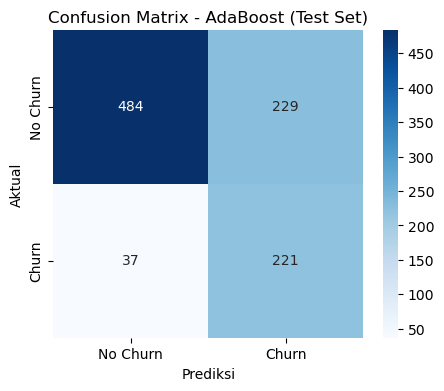

In [95]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel('Prediksi'); plt.ylabel('Aktual'); plt.title('Confusion Matrix - AdaBoost (Test Set)')
plt.show()

Learning Curve Inspection

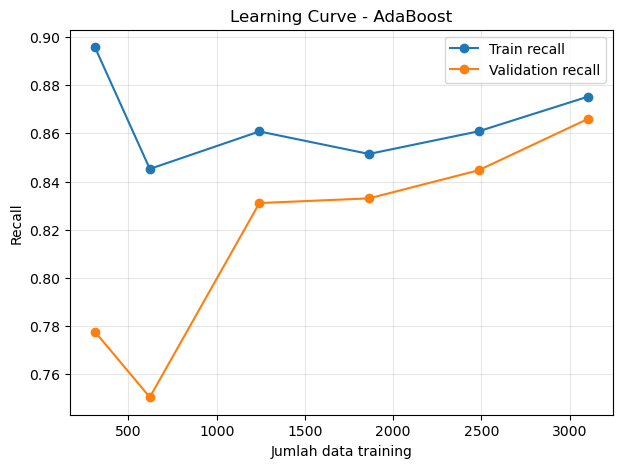

In [96]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, x_train, y_train, cv=5, scoring='recall',
    train_sizes=[0.1,0.2,0.4,0.6,0.8,1.0], random_state=RANDOM_STATE, n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train recall')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation recall')
plt.xlabel('Jumlah data training'); plt.ylabel('Recall'); plt.title('Learning Curve - AdaBoost')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Confusion matrix pada data test menunjukkan model berhasil mendeteksi 221 dari 258 pelanggan churn aktual (recall 85,7%), dengan 229 false positive dan 37 false negative.

**6.6 Model Calibration (Classification Only)**

>   *Tujuan:* Menyesuaikan output probabilitas model supaya lebih merepresentasikan kemungkinan sebenarnya, penting saat threshold dipakai untuk keputusan bisnis.

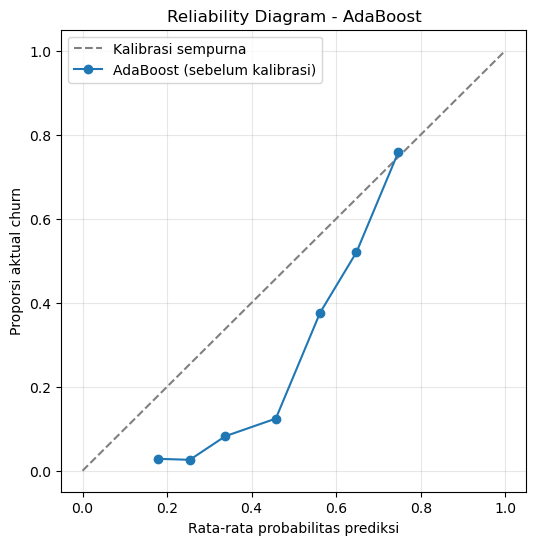

In [97]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Kalibrasi sempurna')
plt.plot(prob_pred, prob_true, marker='o', label='AdaBoost (sebelum kalibrasi)')
plt.xlabel('Rata-rata probabilitas prediksi'); plt.ylabel('Proporsi aktual churn')
plt.title('Reliability Diagram - AdaBoost')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [98]:
from sklearn.calibration import CalibratedClassifierCV

# model terkalibrasi (cv=5)
base_for_calib = clone(pipeline_ros)
base_for_calib.set_params(classifier=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE))

calibrated_model = CalibratedClassifierCV(base_for_calib, method='sigmoid', cv=5)
calibrated_model.fit(x_train, y_train)
y_proba_calibrated = calibrated_model.predict_proba(x_test)[:,1]

c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\yoan.nita\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear'

In [99]:
from sklearn.metrics import brier_score_loss

print('Brier Score (as-is)       :', round(brier_score_loss(y_test, y_proba), 4))
print('Brier Score (terkalibrasi):', round(brier_score_loss(y_test, y_proba_calibrated), 4))

Brier Score (as-is)       : 0.1851
Brier Score (terkalibrasi): 0.1402


**6.7 Model Explanation and Interpretation**
- Feature Importance (Tree Based Model) / Coefficient Regression (Regression Based Model)
- SHAP Value identification
- Counterfactual Analysis

>   *Tujuan:* Menjelaskan bagaimana model mengambil keputusan - penting untuk membangun kepercayaan stakeholder bisnis terhadap model.

Feature Importance - Adaboost

In [100]:
# ambil nama fitur SETELAH feature_selection (karena SelectFpr bisa buang sebagian kolom), menampilkan semua fitur
feature_names_all = final_model.named_steps['preprocess'].get_feature_names_out()
selected_mask = final_model.named_steps['feature_selection'].get_support()
feature_names_selected = feature_names_all[selected_mask]

importances = final_model.named_steps['classifier'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names_selected, 'importance': importances}).sort_values('importance', ascending=False)
fi_df

,feature,importance
12,cat__Contract_Two year,0.450499
14,num_scale__tenure,0.235389
5,cat__InternetService_Fiber optic,0.145915
11,cat__Contract_One year,0.076305
6,cat__InternetService_No,0.034396
7,cat__DeviceProtection_No internet service,0.020180
9,cat__TechSupport_No internet service,0.018983
3,cat__OnlineBackup_No internet service,0.012478
1,cat__OnlineSecurity_No internet service,0.005855
16,num_bin__tenure,0.000000


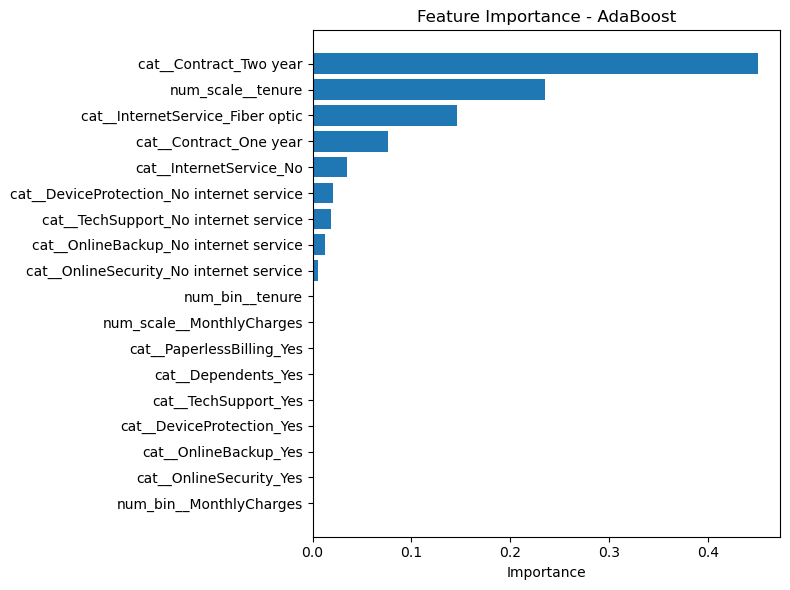

In [101]:
plt.figure(figsize=(8,6))
plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1])
plt.xlabel('Importance'); plt.title('Feature Importance - AdaBoost')
plt.tight_layout()
plt.show()

SHAP Value

## **Section 7. Model Deployment**

>   *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook, lengkap dengan dokumentasi teknis yang diperlukan.

**7.1 Export Model (joblib/pickle)**

>   *Tujuan:* Menyimpan pipeline terlatih ke dalam file yang bisa dimuat ulang tanpa perlu melatih ulang dari awal.

>   Minimal, export pipeline lengkap (bukan cuma model) dengan `joblib.dump()` supaya preprocessing dan model tetap satu paket saat dipakai ulang.

**7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

>   *Tujuan:* Mendokumentasikan hal teknis yang perlu diperhatikan tim lain saat model dipakai di lingkungan produksi.

## **Section 8. Model Implementation**

>   *Tujuan:* Menjelaskan cara pakai model di dunia nyata, batasannya, dan dampak bisnisnya lewat simulasi.

**8.1 How to implement the model?**

>   *Tujuan:* Menjelaskan langkah teknis memakai model untuk melakukan prediksi pada data baru.

**8.2 What are the limitations of the model?**

>   *Tujuan:* Mengakui batasan model secara jujur, termasuk skenario di mana prediksinya kurang bisa diandalkan.

**8.3 Business Calculation (Simulation using unseen data)**

>   *Tujuan:* Mensimulasikan dampak bisnis dari penggunaan model, memakai data `unseen` yang belum pernah dilihat selama proses modeling.

>   Ini saatnya `unseen` data dipakai. Kaitkan hasil simulasi dengan metrik bisnis yang kamu tetapkan di Section 1.5 - misalnya, hitung estimasi kerugian akibat False Negative vs biaya operasional akibat False Positive, sesuai threshold yang dipilih.

## **Section 9. Conclusion and Recommendation**

>   *Tujuan:* Merangkum keseluruhan proyek dan menerjemahkan hasil teknis kembali ke bahasa yang dipahami stakeholder bisnis.

**9.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)

>   *Tujuan:* Merangkum temuan utama dari sisi performa model dan sisi dampak bisnis, menjawab kembali Goals di Section 1.3.

**9.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)

>   *Tujuan:* Memberikan rekomendasi tindak lanjut konkret berdasarkan temuan proyek, baik dari sisi teknis maupun bisnis.